In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

MAIN = Path("/Users/hintont/Dev/projects/ridgecrest")
sys.path.insert(0, str(MAIN / "scripts"))
sys.path.insert(0, "/Users/hintont/Dev/codes/src")

FAULT_DIR = MAIN / "data" / "fault"
FIGURES = Path("figures")   # pre-generated images copied next to this notebook

## 1. Fault meshing

In [2]:
%matplotlib widget
from remeshFault import load_npz

rfs = [load_npz(FAULT_DIR / f) for f in
       ("mainshock_fault_remesh.npz", "foreshock_fault_remesh.npz")]
for rf in rfs:
    print(rf)
    print(f"   depth contours (km): {rf.depths / 1e3}")

RemeshedFault(name='mainshock_fault', 222 patches, 0 contours, datum=542.4 m)
   depth contours (km): [ 0.   1.5  3.   5.5  8.5 11.5 15. ]
RemeshedFault(name='foreshock_fault', 108 patches, 0 contours, datum=564.7 m)
   depth contours (km): [ 0.   1.5  3.   5.5  8.5 11.5 15. ]


**Interactive 3D mesh** — drag to rotate (both strands, coloured by depth layer; note the shared contour vertices and the coarsening with depth):

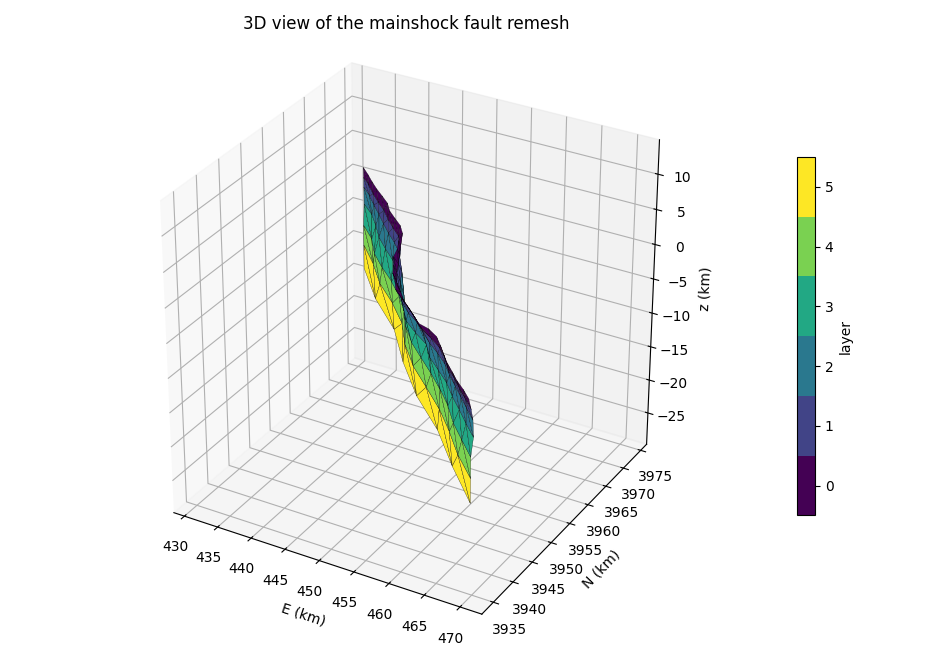

In [7]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from remeshFault_plot import _set_equal_aspect

n_layers = max(int(rf.layers.max()) for rf in rfs) + 1
cmap = plt.get_cmap("viridis", n_layers)
norm = plt.Normalize(-0.5, n_layers - 0.5)

fig = plt.figure(figsize=(9.5, 6.5))
ax = fig.add_subplot(111, projection="3d")
for rf in [rfs[0]]:
    tri_xyz = (rf.vertices * 1e-3)[rf.triangles]          # km
    ax.add_collection3d(Poly3DCollection(tri_xyz, facecolors=cmap(norm(rf.layers)),
                                         edgecolors="k", linewidths=0.2))
_set_equal_aspect(ax, np.vstack([rf.vertices for rf in rfs]) * 1e-3)
ax.set_xlabel("E (km)"); ax.set_ylabel("N (km)"); ax.set_zlabel("z (km)")
ax.set_title("3D view of the mainshock fault remesh")
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.1, ticks=range(n_layers), label="layer")
fig.tight_layout()

FaultTriangles(name='LLFZ', 330 triangles, 206 vertices, datum=542.4 m)


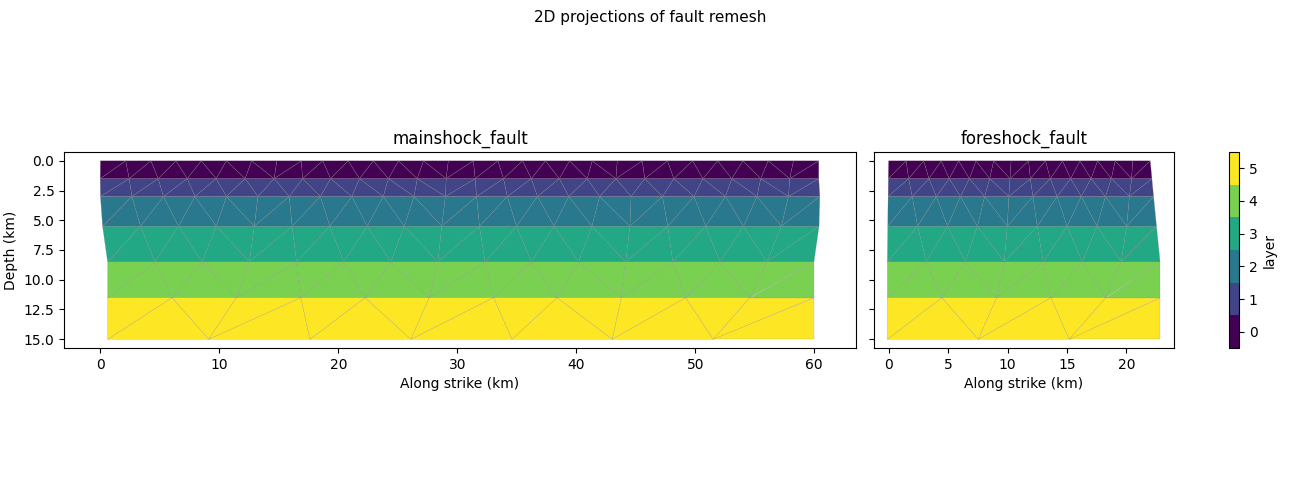

In [8]:
from codes import FaultTriangles

fault = FaultTriangles.merge(
    [FaultTriangles.from_npz(FAULT_DIR / f) for f in
     ("mainshock_fault_remesh.npz", "foreshock_fault_remesh.npz")],
    name="LLFZ")
print(fault)

fig, axes = fault.plot_slip_2d(slip=fault.layers, cmap=cmap,
                               vmin=-0.5, vmax=n_layers - 0.5,
                               colorbar_label="layer")
fig.suptitle("2D projections of fault remesh", fontsize=11);

## 2. Data preparation
![covariance](figures/prep/covariance_fit.png)

## 3. Quick least-squares inversions

N.b. Optical data are never in the fit, just visualised for comparison.

### 3.1 Ascending InSAR only

![slip](figures/lsq_asc/quick_lsq_slip_2d.png)
![fit A064](figures/lsq_asc/quick_lsq_fit_A064.png)
![optical](figures/lsq_asc/quick_lsq_optical_residuals.png)

### 3.2 Descending InSAR only

![slip](figures/lsq_desc/quick_lsq_slip_2d.png)
![fit D071](figures/lsq_desc/quick_lsq_fit_D071.png)
![optical](figures/lsq_desc/quick_lsq_optical_residuals.png)

### 3.3 Ascending + GNSS

![slip](figures/lsq_asc_gnss/quick_lsq_slip_2d.png)
![fit A064](figures/lsq_asc_gnss/quick_lsq_fit_A064.png)
![optical](figures/lsq_asc_gnss/quick_lsq_optical_residuals.png)

### 3.4 Descending + GNSS

![slip](figures/lsq_desc_gnss/quick_lsq_slip_2d.png)
![fit D071](figures/lsq_desc_gnss/quick_lsq_fit_D071.png)
![optical](figures/lsq_desc_gnss/quick_lsq_optical_residuals.png)

### 3.5 Ascending + descending + GNSS

![slip](figures/lsq_asc_desc_gnss/quick_lsq_slip_2d.png)
![fit A064](figures/lsq_asc_desc_gnss/quick_lsq_fit_A064.png)
![fit D071](figures/lsq_asc_desc_gnss/quick_lsq_fit_D071.png)
![optical](figures/lsq_asc_desc_gnss/quick_lsq_optical_residuals.png)

### Summary of Least squares inversions

**Post-fit residual RMS**

| Case | A064 LOS (cm) | D071 LOS (cm) | GNSS (mm) | Optical EW (m) | Optical NS (m) |
|---|---|---|---|---|---|
| Ascending InSAR only (A064) | 10.4 | -- | 57.2* | 0.51 | 0.63 |
| Descending InSAR only (D071) | -- | 7.6 | 17.3* | 0.40 | 0.46 |
| Ascending + GNSS | 11.2 | -- | 15.4 | 0.43 | 0.52 |
| Descending + GNSS | -- | 6.9 | 7.7 | 0.37 | 0.43 |
| Ascending + descending + GNSS | 12.3 | 7.5 | 9.8 | 0.36 | 0.40 |

## 4. AlTar Bayesian inversion

### Data fits

![fit D071](figures/altar/fit_D071.png)
![fit gnss](figures/altar/fit_gnss.png)

Near-field check — optical image correlation (not inverted):
![fit optical](figures/altar/fit_optical_check.png)

### Slip distribution

![bivariate](figures/altar/slip_bivariate.png)

Strike-slip most-likely model:
![ss 2d](figures/altar/slip2d_strikeslip.png)

## 5.Deep-slip only surface displacement


![deep slip](figures/altar/deep_slip_surface_displacement.png)